In [126]:
import numpy as np
from IPython.core.pylabtools import figsize
from matplotlib.patches import Rectangle, Patch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
from scipy.stats import ttest_1samp, t
import PcmPy as pcm
from pcm_cortical import find_model, make_execution_models
import globals as gl
from Plot import add_colorbar, set_spines_and_ticks_width, set_dark_background

from util import r_squared
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use('default')
plt.style.use('dark_background')

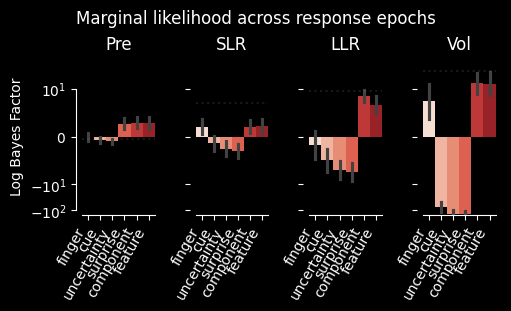

In [127]:
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
experiment = 'smp0'

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'feature')

fig, axs = plt.subplots(1, len(epochs), figsize=(5, 3), sharey=True, constrained_layout=True)

vmin, vmax = -.1, 1.1

for r, epoch in enumerate(epochs):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.{epoch}.p'))
    # T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.{epoch}.pkl'))

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    width=1,
                    palette='Reds',
                    errorbar='se')
    ax.set_xlabel('')
    ax.set_yscale('symlog')
    ax.set_ylim((-150, 150))
    ax.spines[['left',]].set_bounds(-10**2, 10)
    ax.set_yticks([-10**2, -10, 0, 10, ])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
    ax.tick_params(axis='y', which='minor', left=False)

    ax.set_xlim(-1, 6)
    ax.spines[['bottom',]].set_bounds(-.5, 5.5)

    ax.set_title(f'{epoch}')

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)

    else:
        ax.spines[['top', 'right','left']].set_visible(False)

fig.suptitle('Marginal likelihood across response epochs')

plt.show()

In [128]:
# plt.style.use('dark_background')
#
# epochs = ['SLR', 'LLR', 'Vol',]
# experiment = 'smp0'
#
# LL = {
#     'epoch': [],
#     'noise_upper': [],
#     'noise_lower': [],
#     'baseline': [],
#     'likelihood': [],
# }
# for r, epoch in enumerate(epochs):
#
#     T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.{epoch}.pkl'))
#     T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.{epoch}.pkl'))
#
#     # Subtract the baseline
#     LL['likelihood'].extend(T_cv.likelihood.loc[:,'feature'])
#     LL['baseline'].extend(T_cv.likelihood.loc[:,'null'])
#     LL['epoch'].extend([epoch] * len(T_cv.likelihood.loc[:,'feature']))
#     LL['noise_upper'].extend(T_gr.likelihood['ceil'])
#     LL['noise_lower'].extend(T_cv.likelihood.loc[:, 'ceil'])
#
# LL = pd.DataFrame(LL)
# baseline = LL.loc[:,'baseline'].values
# LL[['noise_upper', 'noise_lower', 'likelihood']] = LL[['noise_upper', 'noise_lower', 'likelihood']] - baseline.reshape(-1,1)
# # LL['likelihood_norm'] = LL['likelihood'] / LL['noise_lower']
#
# fig, ax = plt.subplots(figsize=(1.5, 3))
#
# width = .8
#
# color = sns.color_palette('Reds', n_colors=6)[-1]
# ax = sns.barplot(data=LL, x='epoch', y='likelihood', ax=ax, width=width, errorbar='se', color=color)
#
# for r, epoch in enumerate(epochs):
#     noise_upper = LL[LL['epoch'] == epoch]['noise_upper'].mean()
#     noise_lower = LL[LL['epoch'] == epoch]['noise_lower'].mean()
#     # ratio = noise_upper / noise_lower
#     noiserect = Rectangle((r-width/2, noise_lower), width,noise_upper - noise_lower, linewidth=0, facecolor=[0.5, 0.5, 0.5, 0.2], zorder=1e6, alpha=.3)
#     ax.add_patch(noiserect)
#
# ax.set_yscale('symlog', linthresh=10)
# ax.set_ylim(0, 100)
# ax.set_xticks(ax.get_xticks())
# ax.set_ylabel('Log Bayes Factor')
# ax.set_xlabel('')
# ax.spines[['top', 'right',]].set_visible(False)
# ax.spines[['bottom','left']].set_linewidth(2)
# ax.spines[['left',]].set_bounds([0, 100])
# ax.spines[['bottom',]].set_bounds([0, 2])
# ax.tick_params(width=2)
#
# ax.set_title('Maximum likelihood\nunder feature model', pad=10)
#
# plt.show()


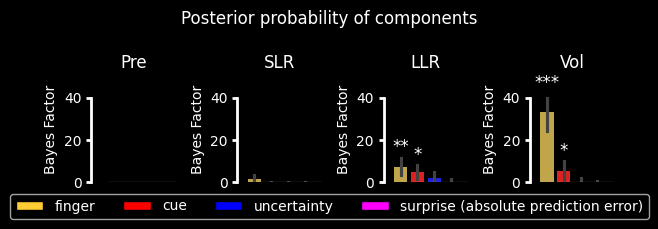

In [129]:
experiment = 'smp0'

components = ['finger', 'cue', 'uncertainty', 'surprise']

epochs = ['Pre', 'SLR', 'LLR', 'Vol']

M = make_execution_models()
M, _ = find_model(M, 'component')
G = M.Gc
MF = pcm.model.ModelFamily(G, comp_names=components, basecomponents=np.eye(8)[None,:,:])

fig, axs = plt.subplots(1, len(epochs), figsize=(6, 2),  constrained_layout=True)

for r, epoch in enumerate(epochs):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.emg.{epoch}.p'))
    plt.sca(axs[r])
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    bars = pcm.vis.plot_component(c_bf, type='bf',palette=['#D4AF37', 'red', 'blue', 'magenta'])

    for i, col in enumerate(c_bf.columns):
        vals = c_bf[col].dropna().values
        vals = vals[np.isfinite(vals)]
        n = len(vals)
        if n < 2:
            continue

        _, p_val_1samp = ttest_1samp(vals, 0, alternative='greater')

        mean = vals.mean()
        sem = vals.std(ddof=1) / (n**0.5)
        ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
        bar_height = mean + ci

        if p_val_1samp < 0.001:
            stars = '***'
        elif p_val_1samp < 0.01:
            stars = '**'
        elif p_val_1samp < 0.05:
            stars = '*'
        else:
            stars = None

        if stars:
            axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)

    axs[r].set_title(epoch)
    axs[r].set_xlabel('')
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(components, rotation=60, ha='right')
    axs[r].hlines(0, 0, 4, color='w', lw=0.8)
    axs[r].spines[['top', 'right', 'bottom']].set_visible(False)
    axs[r].spines[['left', ]].set_bounds(0, 40)
    axs[r].spines[['left', ]].set_linewidth(2)
    # axs[r].set_yticks([-.5, 0, 1, 2])
    axs[r].set_xlim([-1, 4])
    axs[r].set_ylim([0, 50])
    axs[r].spines[['bottom',]].set_bounds(0, 5)
    axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    axs[r].tick_params(width=2)

# Define legend handles
legend_handles = [
    Patch(facecolor='#FFCC33', edgecolor='black', label='finger'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (absolute prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=6,
           fontsize=10)

fig.suptitle('Posterior probability of components')

fig.tight_layout()

plt.show()

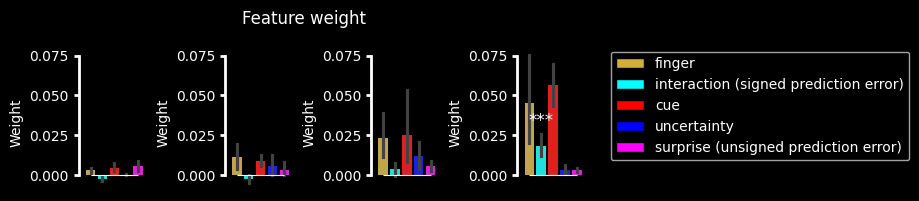

In [130]:
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
experiment = 'smp0'
plt.style.use('dark_background')

features = np.array(['finger', 'interaction','cue', 'uncertainty', 'surprise'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'feature')

Ac = Mf.Ac.sum(axis=0)
n_param = Mf.n_param

vmin, vmax = -0, .001

colors = sns.color_palette("Set3", n_colors=5) #+ [(.5, .5, .5)]
#colors = np.array(colors)[np.array([0, 4, 1, 2, 3])]

fig, axs = plt.subplots(1, len(epochs), figsize=(6, 2))

for r, epoch in enumerate(epochs):

    ax = axs[r]

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.{epoch}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta2 = theta**2
    var_expl = np.vstack([theta2[0,] + theta2[1,], theta[1,] * theta[2,], theta2[2,] + theta2[3,], theta2[4,], theta2[5,]])

    sns.barplot(data=var_expl.T, ax=ax, palette=['#D4AF37', 'cyan', 'red', 'blue', 'magenta'])

    _, p_val_1samp = ttest_1samp(var_expl[1], 0, alternative='greater')

    n = len(var_expl[1])
    mean = np.abs(var_expl[1].mean())
    sem = var_expl[1].std(ddof=1) / (n**0.5)
    ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
    bar_height = np.sign(var_expl[1].mean()) * (mean + ci) * 1.5

    if p_val_1samp < 0.001:
        stars = '***'
    elif p_val_1samp < 0.01:
        stars = '**'
    elif p_val_1samp < 0.05:
        stars = '*'
    else:
        stars = None

    if stars:
        axs[r].text(1, bar_height, stars, ha='center', va='top', fontsize=12)

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(features, rotation=60, ha='right')
    ax.hlines(0, 0, 4, color='w', lw=0.8)
    ax.set_xlim((-1, 5))
    ax.set_ylim((-.01, .076))
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # if r == 0:
    ax.set_ylabel('Weight')
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines['left'].set_bounds(0, .075)
    ax.tick_params(width=2)

fig.suptitle('Feature weight')

# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='interaction (signed prediction error)'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='blue', edgecolor='black', label='uncertainty'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (unsigned prediction error)')
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='center left',
           bbox_to_anchor=(1, .5),
           ncol=1,
           fontsize=10)

fig.tight_layout()

plt.show()

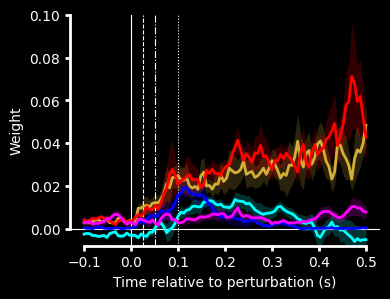

In [136]:
experiment = 'smp0'

npz = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.continuous.npz'), allow_pickle=True)

theta = npz['theta']
descr = npz['descr'].item()

# Preprocess theta
theta2 = theta ** 2
var_expl = np.array([theta2[:, 0] + theta2[:, 1], theta[:, 1] * theta[:, 2] , theta2[:, 2] + theta2[:, 3], theta2[:, 4], theta2[:, 5]])

N = theta.shape[-1]
tAx = [(win[0] + win[1]) / 2 for win in descr['wins'] ]#+.05 #* 1000

# Set up figure
fig, ax = plt.subplots(figsize=(4, 3))

color = ['#D4AF37', 'cyan', 'red', 'blue', 'magenta']

for v, var in enumerate(var_expl):
    ax.plot(tAx, var.mean(axis=-1), color=color[v], lw=2, zorder=1e6,)
    ax.fill_between(tAx, var.mean(axis=-1) - var.std(axis=-1) / np.sqrt(N),
                    var.mean(axis=-1) + var.std(axis=-1) / np.sqrt(N), alpha=0.2, color=color[v], lw=0)

ax.axhline(0, color='w', ls='-', lw=.8)
ax.axvline(0, color='w', ls='-', lw=.8)
ax.axvline(.025, color='w', ls='--', lw=.8)
ax.axvline(.05, color='w', ls='-.', lw=.8)
ax.axvline(.1, color='w', ls=':', lw=.8)

# ax.set_xlim(-.05, .5)
ax.set_ylim(-.008, .1)

ax.set_ylabel('Weight')

ax.set_xlabel('Time relative to perturbation (s)')

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
ax.spines['left'].set_bounds(0, .1)
ax.spines['bottom'].set_bounds(-.1, .5)

ax.tick_params(width=2)

plt.show()


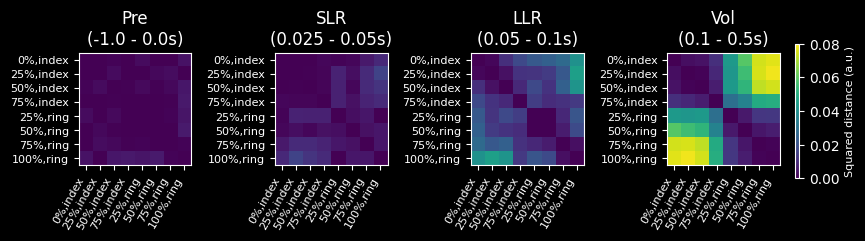

In [132]:
vmin, vmax = -0., .08

wins = [(-1.0, 0.0), (.025, .05), (.05, .1), (.1, .5)]
epochs = ['Pre', 'SLR', 'LLR', 'Vol']

fig, axs = plt.subplots(1, 4, figsize=(8, 4))

for w, win in enumerate(wins):
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epochs[w]}.npy'))
    D = pcm.G_to_dist(G_obs.mean(axis=(0,)))

    ax = axs[w]

    cax = ax.imshow(D, vmin=vmin, vmax=vmax)
    ax.set_title(f'{epochs[w]}\n({win[0]} - {win[1]}s)')

    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)
    ax.set_xticks(ax.get_yticks())
    ax.set_xticklabels(ax.get_yticklabels(), fontsize=8, rotation=60, ha='right')

# Colorbar for imshow (top row)
bbox = axs[0].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.005, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('Squared distance (a.u.)', fontsize=8)

fig.tight_layout()

plt.show()